CNN

1: Importación de Librerías y Configuración de Semillas

In [1]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Forzar reproducibilidad absoluta
np.random.seed(42)
tf.random.set_seed(42)

BASE_DIR = './x-rays'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'validation')
LEADERBOARD_DIR = os.path.join(BASE_DIR, 'leaderboard')
SUBMISSION_PATH = os.path.join(BASE_DIR, 'submission_levi_6.csv')

2: Pipeline de Carga con Flujo Optimizada (tf.data)

In [2]:
# Carga estructurada de datos en escala de grises
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    color_mode='grayscale',
    image_size=(256, 256),
    batch_size=32,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    color_mode='grayscale',
    image_size=(256, 256),
    batch_size=32,
    shuffle=False
)

# Guardar mapeo exacto de clases generado por el sistema de archivos
class_names = train_ds.class_names
print("Mapeo oficial de entrenamiento:", {i: name for i, name in enumerate(class_names)})

# Extraer etiquetas de validación reales para evaluación
y_val = np.concatenate([y for _, y in val_ds], axis=0)

# Optimización de lectura en memoria
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 351 files belonging to 3 classes.
Found 90 files belonging to 3 classes.
Mapeo oficial de entrenamiento: {0: 'COVID-19', 1: 'HEALTHY', 2: 'PNEUMONIA'}


3: Definición del Modelo de Red Neuronal Robustecido

In [3]:
from tensorflow.keras import layers, models, optimizers, callbacks

# 1. Reconstrucción de una Arquitectura Robusta, Ligera y Estable
model = models.Sequential([
    layers.Input(shape=(256, 256, 1)),
    layers.Rescaling(1./255),
    
    # Bloque 1: Filtros pequeños para capturar bordes base
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # Reduce a 128x128
    
    # Bloque 2: Captura de densidades medias
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # Reduce a 64x64
    
    # Bloque 3: Mayor abstracción
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # Reduce a 32x32
    
    # Bloque 4: Reducción crucial para evitar que explote la capa densa
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)), # Reduce a 16x16 -> Muy importante para aligerar la red
    
    # Clasificador Compacto (Pasamos de 33 millones a solo 4 millones de parámetros)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4), # Evita que se memoricen los datos de train
    layers.Dense(len(class_names), activation='softmax')
])

# Compilación con tasa estándar segura
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['acc']
)

model.summary()

# 2. Configuración de Entrenamiento Controlado
# Damos más tolerancia (patience=7) para permitir que el modelo converja correctamente
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True,
    verbose=1
)

# Entrenamos el modelo
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,324,419 (16.50 MB)

 Trainable params: 4,324,419 (16.50 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


c:\Users\Alumne_mati1\Documents\machine_learning_course_cifo_2026\.venv_py312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 506ms/step - acc: 0.4160 - loss: 1.0790 - val_acc: 0.8111 - val_loss: 1.0307
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 502ms/step - acc: 0.6296 - loss: 0.9836 - val_acc: 0.6556 - val_loss: 0.8803
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 510ms/step - acc: 0.6980 - loss: 0.8119 - val_acc: 0.7889 - val_loss: 0.6625
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 550ms/step - acc: 0.7550 - loss: 0.6174 - val_acc: 0.8778 - val_loss: 0.4844
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 544ms/step - acc: 0.7920 - loss: 0.5322 - val_acc: 0.8222 - val_loss: 0.4856
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 542ms/step - acc: 0.8006 - loss: 0.4840 - val_acc: 0.8556 - val_loss: 0.3926
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 599ms/step - acc: 0.8462 - loss: 0.4300 - val_acc: 0.9222 - val_loss: 0.3247
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 566ms/step - acc: 0.8860 - loss: 0.3633 - val_acc: 0.9111 - val_loss: 0.2917
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 584ms/step - acc: 0.8746 -

4: Entrenamiento con Callbacks Inteligentes

5: Validación Local y Reporte de Métricas

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step

--- REPORTE DE CLASIFICACIÓN LOCAL ---
              precision    recall  f1-score   support

    COVID-19       0.97      0.97      0.97        30
     HEALTHY       1.00      0.97      0.98        30
   PNEUMONIA       0.94      0.97      0.95        30

    accuracy                           0.97        90
   macro avg       0.97      0.97      0.97        90
weighted avg       0.97      0.97      0.97        90



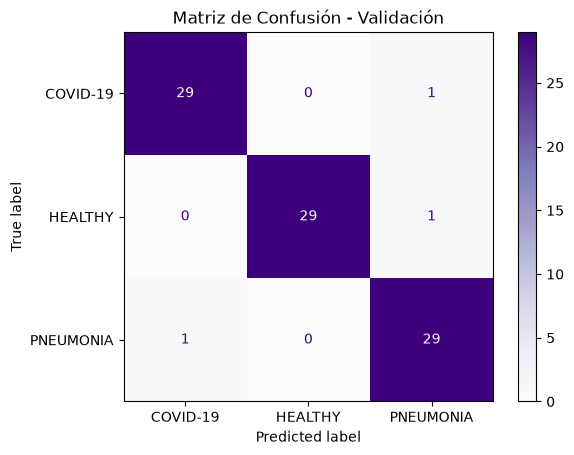

In [4]:
# Evaluación local
val_preds = model.predict(val_ds)
y_pred = np.argmax(val_preds, axis=1)

print("\n--- REPORTE DE CLASIFICACIÓN LOCAL ---")
print(classification_report(y_val, y_pred, target_names=class_names))

ConfusionMatrixDisplay.from_predictions(y_val, y_pred, display_labels=class_names, cmap=plt.cm.Purples)
plt.title("Matriz de Confusión - Validación")
plt.show()

6: Generación del Archivo de Submission con Formato Estricto y Seguro

In [5]:
def generar_submission_ganadora(modelo, carpeta_leaderboard, ruta_csv):
    ids_lista = []
    pred_lista = []
    
    archivos = [f for f in os.listdir(carpeta_leaderboard) if f.endswith('.png')]
    archivos.sort(key=lambda var: [int(x) if x.isdigit() else x for x in re.split(r'(\d+)', var)])
    
    print(f"Procesando {len(archivos)} imágenes...")
    
    for archivo in archivos:
        id_numerico = int(archivo.split('.')[0])
        ruta_img = os.path.join(carpeta_leaderboard, archivo)
        
        # Carga idéntica
        img = tf.keras.utils.load_img(ruta_img, color_mode='grayscale', target_size=(256, 256))
        img_array = tf.keras.utils.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        
        preds = modelo.predict(img_array, verbose=0)
        clase_predicha = np.argmax(preds, axis=1)[0]
        
        ids_lista.append(id_numerico)
        pred_lista.append(clase_predicha)
        
    df_sub = pd.DataFrame({'id': ids_lista, 'prediction': pred_lista})
    df_sub.to_csv(ruta_csv, index=False)
    print(f"¡CSV definitivo generado con éxito en: {ruta_csv}!")
    return df_sub

df_entrega = generar_submission_ganadora(model, LEADERBOARD_DIR, SUBMISSION_PATH)
print(df_entrega.head())

Procesando 116 imágenes...
¡CSV definitivo generado con éxito en: ./x-rays\submission_levi_6.csv!
   id  prediction
0   1           0
1   2           1
2   3           1
3   4           0
4   5           0
